# d65: Enumerated Catalyst Compatibility

The 100-catalyst screen exposed two assumptions in the assembly code:

1. every catalyst boron was assumed to be **BH2**;
2. every nitrogen match was assumed to be the catalyst Lewis base.

This notebook shows the molecular cases that required the fixes and two representative 3D TS guesses. It does not submit calculations or modify FRUST.

In [1]:
import pandas as pd
from rdkit import Chem

import frust as ft
from frust.tsguess.matching import match_catalyst_roles
from frust.vis.molecules import _row_to_mol

## 1. The Catalyst Cases

The highlighted atoms are the B–aryl–N catalyst roles selected by FRUST. Hydrogens are made explicit only on boron.

- The **B–F** example is BH rather than BH2. FRUST must not invent a second spectator B–H bond.
- The **NO2** and extra **NMe2** examples contain other nitrogen atoms. FRUST must still select the neutral tertiary amine belonging to the B–aryl–N scaffold.

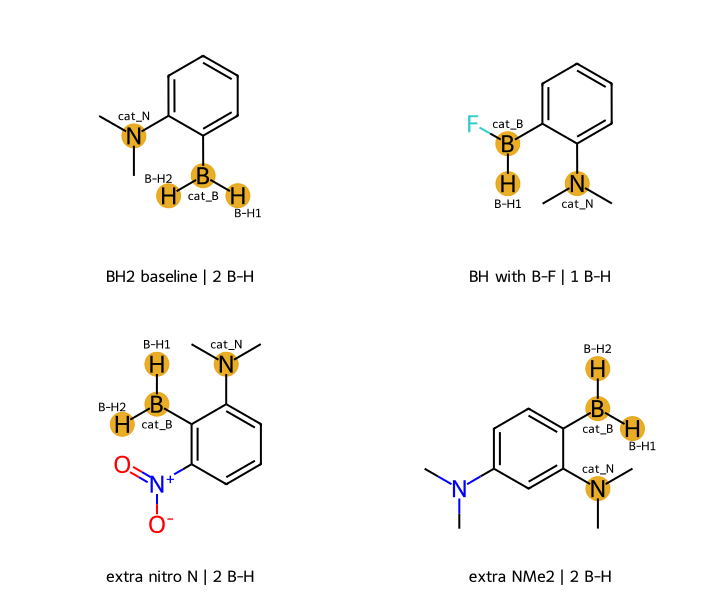

In [2]:
catalyst_smiles = {
    "BH2 baseline": "Bc1ccccc1N(C)C",
    "BH with B-F": "CN(C)c1ccccc1BF",
    "extra nitro N": "Bc1c([N+](=O)[O-])cccc1N(C)C",
    "extra NMe2": "Bc1ccc(N(C)C)cc1N(C)C",
}

catalyst_mols = []
catalyst_highlights = []
catalyst_legends = []

for name, smiles in catalyst_smiles.items():
    mol = Chem.MolFromSmiles(smiles)
    roles = match_catalyst_roles(mol, catalyst_name=name)
    mol = Chem.AddHs(mol, onlyOnAtoms=[roles["cat_B"]])

    mol.GetAtomWithIdx(roles["cat_B"]).SetProp("atomNote", "cat_B")
    mol.GetAtomWithIdx(roles["cat_N"]).SetProp("atomNote", "cat_N")
    b_hydrogens = [
        atom.GetIdx()
        for atom in mol.GetAtomWithIdx(roles["cat_B"]).GetNeighbors()
        if atom.GetAtomicNum() == 1
    ]
    for number, atom_idx in enumerate(b_hydrogens, start=1):
        mol.GetAtomWithIdx(atom_idx).SetProp("atomNote", f"B-H{number}")

    catalyst_mols.append(mol)
    catalyst_highlights.append([roles["cat_B"], roles["cat_N"], *b_hydrogens])
    catalyst_legends.append(f"{name} | {len(b_hydrogens)} B-H")

ft.DrawMolSvg(
    catalyst_mols,
    w=360,
    h=300,
    columns=2,
    legends=catalyst_legends,
    highlight_atom_indices=catalyst_highlights,
)

## 2. What Changed In FRUST

| Assembly step | New behavior |
|---|---|
| Catalyst role matching | Match the neutral, tertiary N in the B–aryl–N scaffold; ignore nitro, amino, amide, and unrelated tertiary N atoms |
| Dimers and cycle molecules | Accept either one or two B–H atoms |
| TS1/TS2 construction | Use the shared catalyst-role matcher instead of selecting the first tertiary amine |
| TS3/TS4 construction | Add a spectator catalyst hydrogen only for BH2; BH catalysts keep their real substituent on B |

The implementation is in `frust/tsguess/matching.py`, `frust/transformers.py`, and `frust/tsguess2/builders.py`.

## 3. Representative 3D TS Guesses

Two examples exercise the actual screen assembly path:

- **TS3 with B–F:** the catalyst boron has only one B–H hydrogen and retains F.
- **TS1 with an extra NMe2:** the highlighted `cat_N` is the amine connected to the B-bearing aromatic scaffold.

Click an atom to toggle its label. Ctrl-click two atoms to measure a distance.

In [3]:
components = ft.screen.read(
    pd.DataFrame(
        {
            "role": ["substrate", "substrate", "catalyst", "catalyst"],
            "smiles": [
                "COC1=CC=CC(OC)=C1",
                "CC1=CC=CC(N(C)C)=C1",
                catalyst_smiles["BH with B-F"],
                catalyst_smiles["extra NMe2"],
            ],
            "compound_name": [
                "dimethoxybenzene",
                "dimethyl_m_toluidine",
                "B-F catalyst",
                "extra NMe2 catalyst",
            ],
            "rpos": ["3", "2", None, None],
        }
    )
)
systems = ft.screen.expand(components)
guesses = ft.screen.create_ts_guesses(
    systems,
    ts_types=["TS1", "TS3"],
    n_confs=1,
)

ts3_bf = guesses["TS3"].query(
    "substrate_name == 'dimethoxybenzene' and catalyst_name == 'B-F catalyst'"
).iloc[0]
ts1_nme2 = guesses["TS1"].query(
    "substrate_name == 'dimethyl_m_toluidine' and catalyst_name == 'extra NMe2 catalyst'"
).iloc[0]

pd.DataFrame(
    [
        {
            "example": "TS3 / B-F catalyst",
            "rpos": ts3_bf["rpos"],
            "roles": tuple(ts3_bf["constraint_roles"]),
        },
        {
            "example": "TS1 / extra NMe2 catalyst",
            "rpos": ts1_nme2["rpos"],
            "roles": tuple(ts1_nme2["constraint_roles"]),
        },
    ]
)

,example,rpos,roles
0,TS3 / B-F catalyst,3,"(cat_B, transfer_H, pin_B, substrate_C)"
1,TS1 / extra NMe2 catalyst,2,"(transfer_H, cat_N, cat_B, substrate_C)"


In [4]:
def role_labelled_mol(row):
    """Return a molecule carrying labels for its constrained roles."""
    mol = Chem.Mol(_row_to_mol(row, row["atoms"], row["coords_embedded"]))
    for role, atom_idx in row["constraint_roles"].items():
        mol.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", role)
    return mol

example_rows = [ts3_bf, ts1_nme2]
ft.MolTo3DGrid(
    [role_labelled_mol(row) for row in example_rows],
    legends=[
        "TS3: BH catalyst retains B-F",
        "TS1: correct scaffold N selected",
    ],
    highlightAtoms=[
        list(row["constraint_roles"].values()) for row in example_rows
    ],
    show_labels=True,
    show_confs=False,
    columns=2,
    linked=False,
    cell_size=(520, 440),
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 4. Screen Result

After these changes, the actual p14 input passed assembly for **all 1,806 planned structures**: 800 TS guesses, 404 references, 402 cycle molecules, and 200 INT3 structures.